<a href="https://colab.research.google.com/github/UnitForDataScience/Data_Viz_Python_101_Workshop/blob/main/Colab%20Notebooks/Telling_Your_Story_Women_Representation_in_Movie_Media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telling your Story: Data Visualization 101 with Python
# Worksheet

By ASU Library's Unit for Data Science and Analytics

## Loading and Inspecting the first few rows of the dataset
First things first. In the following code cell we will import our libraries, load our data set to the notebook, and print the first 5 rows of the DataFrame to understand its structure and content.

In [1]:
#Import our libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URL of our dataset housed in GitHub
url = 'https://raw.githubusercontent.com/UnitForDataScience/Data_Viz_Python_101_Workshop/refs/heads/main/Datasets/movies.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)

# Display first five rows
display(df.head())

,year,title,test,binary,budget,domgross,intgross,budget_2026$,domgross_2026$,intgross_2026$
0,2013,21 &amp; Over,notalk,FAIL,13000000,25682380.0,42195766.0,18070000,35698508.0,58652115.0
1,2012,Dredd 3D,ok,PASS,45000000,13414714.0,40868994.0,63465642,18919410.0,57639487.0
2,2013,12 Years a Slave,notalk,FAIL,20000000,53107035.0,158607035.0,27800000,73818779.0,220463779.0
3,2013,2 Guns,notalk,FAIL,61000000,75612460.0,132493015.0,84790000,105101319.0,184165291.0
4,2013,42,men,FAIL,40000000,95020213.0,95020213.0,55600000,132078096.0,132078096.0


## Checking data types and non-null values

It's important to understand the data types of each column and identify if there are any missing values. This helps in data cleaning and feature engineering later on.

In [2]:
#Show data types and any null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1794 entries, 0 to 1793
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            1794 non-null   int64  
 1   title           1794 non-null   object 
 2   test            1794 non-null   object 
 3   binary          1794 non-null   object 
 4   budget          1794 non-null   int64  
 5   domgross        1777 non-null   float64
 6   intgross        1783 non-null   float64
 7   budget_2026$    1794 non-null   int64  
 8   domgross_2026$  1776 non-null   float64
 9   intgross_2026$  1783 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 140.3+ KB


##Descriptive statistics for numerical columns

This will provide a quick summary of the central tendency, dispersion, and shape of the distribution of numerical data. It includes count, mean, standard deviation, minimum, maximum, and quartile values.

Note that this is for the overall dataset, you could specify a year to make this more relevant to your exploration

In [3]:
# Show descriptive stats for all numerical columns except year
df.drop(columns=['year']).describe()

# Example: Filter for a specific year (e.g., 2005) and then describe
#df_by_year = df[df['year'] == 2005]
#display(df_by_year.describe())


# Example: Filter for a range of years (or decades) and then describe
#start_year = 2000
#end_year = 2010
#df_filtered_range = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
#display(df_filtered_range.describe())

,budget,domgross,intgross,budget_2026$,domgross_2026$,intgross_2026$
count,1.794000e+03,1.777000e+03,1.783000e+03,1.794000e+03,1.776000e+03,1.783000e+03
mean,4.482646e+07,6.913205e+07,1.503857e+08,7.709581e+07,1.322929e+08,2.749948e+08
std,4.818603e+07,8.036731e+07,2.103353e+08,7.633690e+07,1.750918e+08,3.940760e+08
min,7.000000e+03,0.000000e+00,8.280000e+02,1.199800e+04,1.250000e+03,1.250000e+03
25%,1.200000e+07,1.631157e+07,2.612947e+07,2.233580e+07,2.855977e+07,4.619332e+07
50%,2.800000e+07,4.219406e+07,7.648246e+07,5.142414e+07,7.783116e+07,1.337731e+08
75%,6.000000e+07,9.335492e+07,1.898509e+08,1.088897e+08,1.691329e+08,3.356558e+08
max,4.250000e+08,7.605076e+08,2.783919e+09,6.413959e+08,2.462639e+09,4.408984e+09


##Exploring Categories

Some of the most important data in our dataset is of a categorical nature, so to keep exploring it, we can use some functions that will tell us a bit more about the variables we have.

Note that you can take this further by looking at specific years or decades.

Value counts for 'test' results:
test
ok         803
notalk     514
men        194
dubious    142
nowomen    141
Name: count, dtype: int64

Value counts for 'binary' (Pass/Fail):
binary
FAIL    991
PASS    803
Name: count, dtype: int64


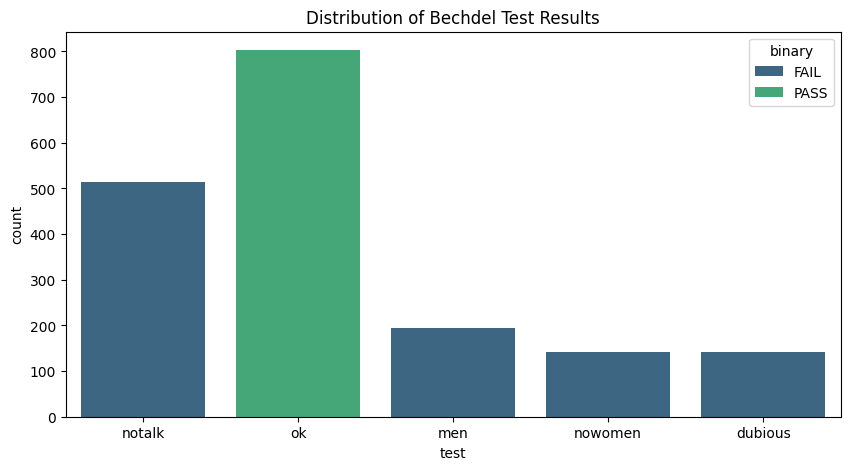

In [4]:
#Explore categorical distributions
print("Value counts for 'test' results:")
print(df['test'].value_counts())

print("\nValue counts for 'binary' (Pass/Fail):")
print(df['binary'].value_counts())

# Visualize categorical data

# Create the plot figure and set its size (width, height)
plt.figure(figsize=(10, 5))

# Build a simple plot using Seaborn
sns.countplot(data=df, x='test', hue='binary', palette='viridis')

# Add our labels
plt.title('Distribution of Bechdel Test Results')

# Show the final plot
plt.show()

###Bechdel Test Categories
The most frequent result is 'ok' (803), which corresponds to passing the test. However, the combined count of the other categories shows a significant number of movies that fall short in various ways (e.g., 'notalk' means women don't talk to each other).

Pass vs. Fail: Overall, 991 movies in this dataset failed the test, while 803 passed.

## A Simple Chart

Here is a simple bar plot to get you going!

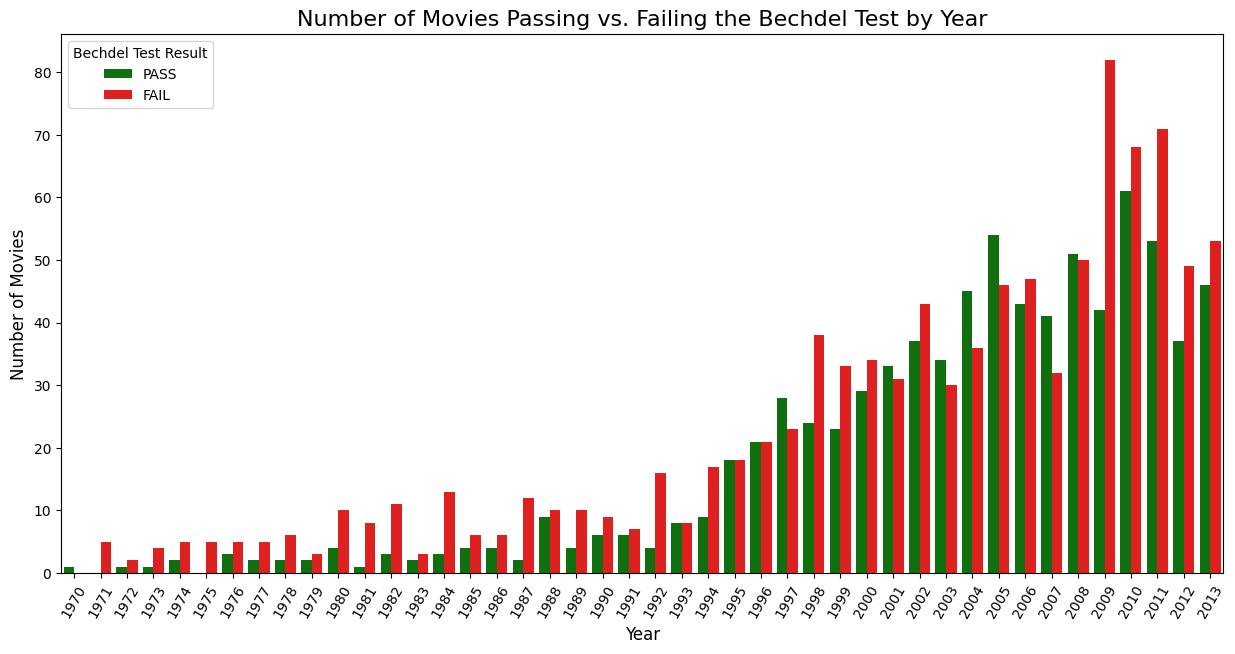

In [15]:
# Create the plot figure and set its size (width, height)
plt.figure(figsize=(15, 7))

# Build a simple plot using Seaborn
sns.countplot(data=df, x='year', hue='binary', palette={'PASS': 'green', 'FAIL': 'red'})

# Add our labels
plt.title('Number of Movies Passing vs. Failing the Bechdel Test by Year', fontsize=16)

#Set Fontsize
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=60)

plt.legend(title='Bechdel Test Result')

# Adjust layout to prevent labels from overlapping
#plt.tight_layout()

# Show the final plot
plt.show()

#Your mission:

Let’s imagine you are part of a team of media studies researchers and data scientists collaborating to study women’s representation in movie media. For decades, a persistent myth in Hollywood has claimed that movies focusing on female characters are financial risks. Your research team is tasked with investigating both the historical progress of women’s representation (Track 1, beginner friendly) and the past and current financial realities surrounding women’s meaningful representation in movies (Track 2, intermediate).

Your goal here is to create two to three visualizations that you can use to tell a short, but relevant story.  